# Testing if the integrator works

In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
from simulation import Simulation
from wisdom_holman import WisdomHolman
from WH_SAB_P import WisdomHolman_SAB_P
from particles import Particles
from particle import Particle
from data_io import DataIO
import constants
from physics import Physics
import h5py
import tools
import matplotlib.pyplot as plt

---

In [29]:
particles = Particles(constants.G, system_type='S(AB)-P')

# Star A: placed at origin; all other bodies orbit relative to it or its COM with B.
particles.add_particle(Particle(
    ptype=0, mass=0.69, radius=0.00465047, name='star A',
    temperature=5772.0,
    pos=[0.0, 0.0, 0.0], vel=[0.0, 0.0, 0.0],
    index='A'
))

# Star B: orbits star A — gives the binary its relative separation and velocity.
particles.add_particle(Particle(
    ptype=0, mass=0.20, radius=4.26352e-5, name='star B',
    a=0.22, e=0.0, inc=0.0, Omega=0.0, omega=0.0, theta=0.0,
    angles_in_degrees=False, index='B', primary='star A'
))

# Star C: outer companion — orbits the binary centre of mass (A+B).
particles.add_particle(Particle(
    ptype=0, mass=0.50, radius=4.26352e-5, name='star C',
    a=20.0, e=0.1167, inc=0.0, Omega=0.0, omega=0.0, theta=0.0,
    angles_in_degrees=False, index='C', primary=['star A', 'star B']
))

# Planet: circumbinary — orbits the binary centre of mass (A+B).
particles.add_particle(Particle(
    ptype=1, mass=1.0e-3, radius=4.26352e-5, name='planet 1',
    a=0.7, e=0.05, inc=0.0, Omega=0.0, omega=0.0, theta=0.0,
    angles_in_degrees=False, index='P', primary=['star A', 'star B']
))

# Shift to the system centre-of-mass frame (COM at rest at origin).
m = particles.masses
r_com = (m[:, None] * particles.pos).sum(axis=0) / m.sum()
v_com = (m[:, None] * particles.vel).sum(axis=0) / m.sum()
particles._pos -= r_com[None, :]
particles._vel -= v_com[None, :]
particles._sync_objects()

print(particles._particles)
print("star_indices:", particles.star_indices)
print("planet_indices:", particles.planet_indices)
print(f"COM position: {(particles.masses[:, None] * particles.pos).sum(axis=0) / particles.masses.sum()}")
print(f"COM velocity: {(particles.masses[:, None] * particles.vel).sum(axis=0) / particles.masses.sum()}")

[Particle(name='star A', ptype=0, m=0.69, r=0.00465047, pos=[-6.4000241116648775, 0.0, 0.0], vel=[0.0, -3.514727928646726, 0.0], hash=887677397), Particle(name='star B', ptype=0, m=0.2, r=4.26352e-05, pos=[-6.180024111664878, 0.0, 0.0], vel=[0.0, 9.122840822695458, 0.0], hash=736285824), Particle(name='star C', ptype=0, m=0.5, r=4.26352e-05, pos=[11.315414090582316, 0.0, 0.0], vel=[0.0, 1.1876328428242826, 0.0], hash=403468359), Particle(name='planet 1', ptype=1, m=0.001, r=4.26352e-05, pos=[-5.685585909417687, 0.0, 0.0], vel=[0.0, 6.777684815006408, 0.0], hash=953850580)]
star_indices: [0 1 2]
planet_indices: [3]
COM position: [-6.98378969e-17  0.00000000e+00  0.00000000e+00]
COM velocity: [ 0.00000000e+00 -8.73597265e-16  0.00000000e+00]


In [30]:
P_bin = 2.0 * np.pi * np.sqrt(0.22**3 / (constants.G * (0.69+0.20)))

In [36]:
P_bin / 20.0

np.float64(0.005469013837937381)

In [33]:
run = Simulation(particles=particles, integrator=WisdomHolman_SAB_P(), dataio=DataIO(const_g=constants.G), physics=Physics())

run.run(t0=0.0, tf=100, dt = P_bin / 20.0, output_every_n=1, handle_collisions=False)

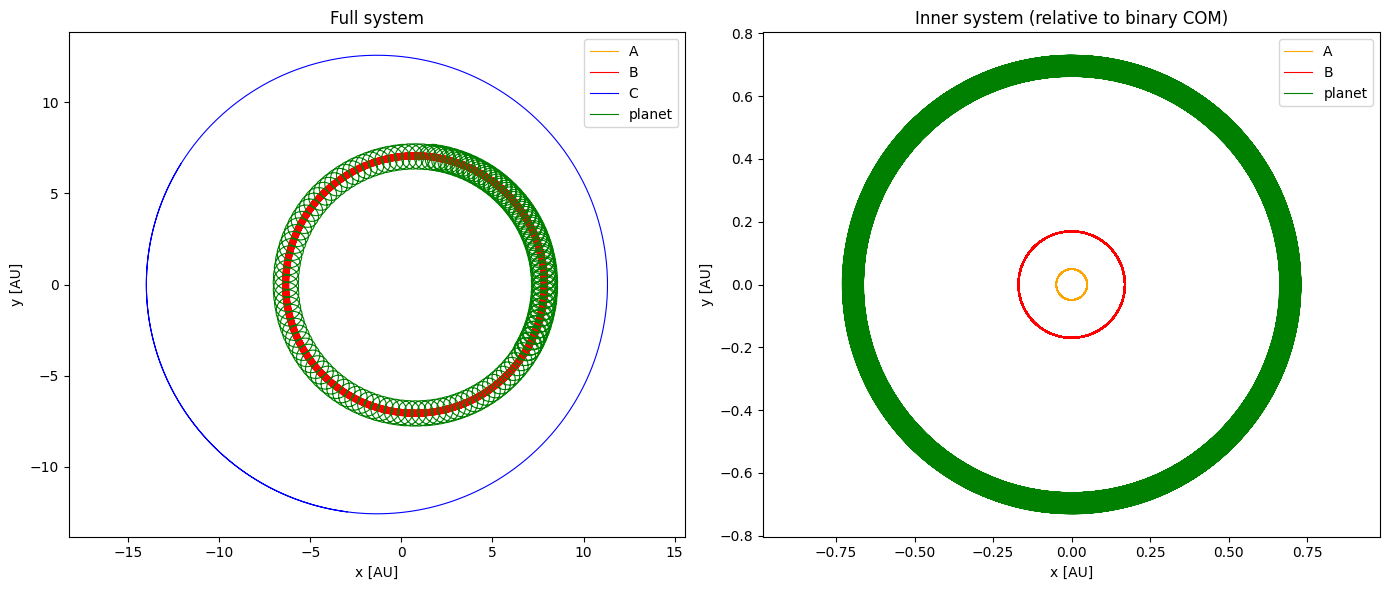

t range: 0.000 → 100.001 yr,  steps: 18286


In [34]:
H5_PATH = "data.hdf5"

with h5py.File(H5_PATH, "r") as f:
    keys = sorted(
        [k for k in f.keys() if k.startswith("Step_")],
        key=lambda s: int(s.split("_")[1])
    )
    t_list, pos_list = [], []
    for k in keys:
        g = f[k]
        t_list.append(g["time"][:])
        pos_list.append(g["pos"][:])

t   = np.concatenate(t_list)
pos = np.concatenate(pos_list)

# Particle storage order: A=0, B=1, C=2, planet=3
if pos.ndim == 2:
    pos = pos.reshape(pos.shape[0], pos.shape[1] // 3, 3)

iA, iB, iC, iP = 0, 1, 2, 3
mA, mB = 0.69, 0.20
mb = mA + mB

# Binary COM position at each step (for centering inner-orbit plots)
r_com_bin = (mA * pos[:, iA, :] + mB * pos[:, iB, :]) / mb

# --- Plot 1: full system (all 4 bodies) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.set_title("Full system")
for idx, label, color in [(iA, "A", "orange"), (iB, "B", "red"),
                           (iC, "C", "blue"),  (iP, "planet", "green")]:
    mask = np.isfinite(pos[:, idx, 0])
    ax.plot(pos[mask, idx, 0], pos[mask, idx, 1], label=label, lw=0.8, color=color)
ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]")
ax.axis("equal"); ax.legend()

# --- Plot 2: inner system relative to binary COM ---
ax = axes[1]
ax.set_title("Inner system (relative to binary COM)")
for idx, label, color in [(iA, "A", "orange"), (iB, "B", "red"), (iP, "planet", "green")]:
    mask = np.isfinite(pos[:, idx, 0])
    ax.plot(pos[mask, idx, 0] - r_com_bin[mask, 0],
            pos[mask, idx, 1] - r_com_bin[mask, 1],
            label=label, lw=0.8, color=color)
ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]")
ax.axis("equal"); ax.legend()

plt.tight_layout()
plt.show()

print(f"t range: {t[0]:.3f} → {t[-1]:.3f} yr,  steps: {len(t)}")

E0 = -12.85338381259801
max |ΔE/E0| = 1.4675005294765014e-06


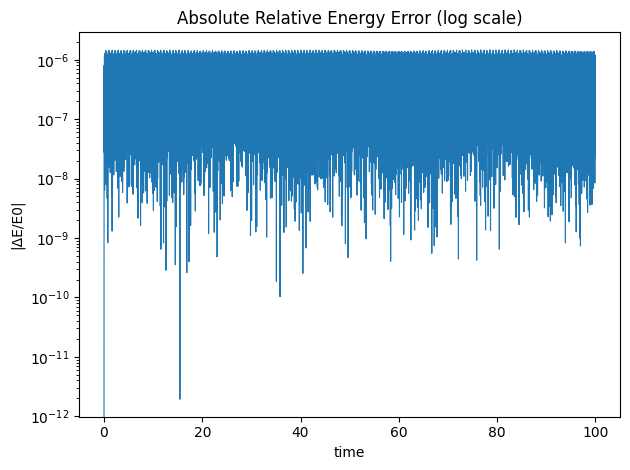

[-12.85338381 -12.85338154 -12.85337895 -12.85337649 -12.85337458
 -12.85337355 -12.8533736  -12.85337469 -12.8533766  -12.85337896]


In [35]:
with h5py.File(H5_PATH, "r") as f:
    keys = sorted(
        [k for k in f.keys() if k.startswith("Step_")],
        key=lambda s: int(s.split("_")[1])
    )

    energy_list, t_list = [], []
    for k in keys:
        g = f[k]
        t_list.append(g["time"][:])
        energy_list.append(g["energy"][:])
       

energy = np.concatenate(energy_list)
t = np.concatenate(t_list)

mask = np.isfinite(energy) & np.isfinite(t)
t = t[mask]
energy = energy[mask]

E0 = energy[0]
dE = energy - E0
rel = dE / abs(E0)

print("E0 =", E0)
print("max |ΔE/E0| =", np.max(np.abs(rel)))

plt.figure()

# Absolute relative error (paper-style)
plt.semilogy(t, np.abs(dE/E0), lw=0.8)
plt.xlabel("time")
plt.ylabel("|ΔE/E0|")
plt.title("Absolute Relative Energy Error (log scale)")

plt.tight_layout()
plt.show()


print(energy[:10])